# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'X': [x_values], 'Y': [y_values]})
~~~~

In [38]:
import pandas as pd


In [43]:
student_data = pd.DataFrame({'X': [17,51,27,21,36,48,19,26,54,30], 'Y': [10,1,5,9,4,2,9,6,0,3]})
student_data

,X,Y
0,17,10
1,51,1
2,27,5
3,21,9
4,36,4
5,48,2
6,19,9
7,26,6
8,54,0
9,30,3


Draw a dispersion diagram (scatter plot) for the data.

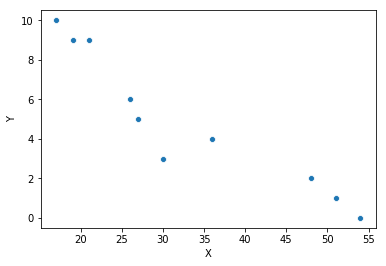

In [44]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='X', y='Y', data=student_data)

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

In [2]:
# it looks that nb of tardies is higher for young student, the more the age increase the more the nb of tardies decrease

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [46]:
print(np.cov(student_data.X, student_data.Y))
print(student_data.corr())
# correlation is a normalized result that we can interpret to compare the 2 variables; 
# covariance is a result which does not show the relation between the 2 variables unless both variables are on the same scale which is not the case here

[[187.65555556 -45.56666667]
 [-45.56666667  12.54444444]]
          X         Y
X  1.000000 -0.939163
Y -0.939163  1.000000


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [49]:
import statsmodels.api as sm

student_data.info()

X=student_data.drop('Y', axis=1)
y=student_data.Y

from statsmodels.tools.tools import add_constant
X=add_constant(X)

model=sm.OLS(y,X)
model_fit=model.fit()
model_fit.summary()

# linear regression model.outcome variable is the tardies prediction 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
X    10 non-null int64
Y    10 non-null int64
dtypes: int64(2)
memory usage: 240.0 bytes


C:\Users\anast\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)
C:\Users\anast\Anaconda3\lib\site-packages\scipy\stats\stats.py:1416: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     59.81
Date:                Mon, 09 Sep 2019   Prob (F-statistic):           5.57e-05
Time:                        15:05:43   Log-Likelihood:                -15.622
No. Observations:                  10   AIC:                             35.24
Df Residuals:                       8   BIC:                             35.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.8888      1.111     11.605      0.000      10.328      15.450
X             -0.2428      0.031     -7.734      0.000      -0.315      -0.170
==============================================================================
Omnibus:                        3.949   Durbin-Watson:                   1.754
Prob(Omnibus):                  0.139   Jarque-Bera (JB):                1.714
Skew:                          -1.014   Prob(JB):                        0.424
Kurtosis:                       3.069   Cond. No.                         96.4
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Plot your regression model on your scatter plot.

In [59]:
  
model_fit.predict(X)

0    8.760850
1    0.504944
2    6.332643
3    7.789567
4    4.147256
5    1.233406
6    8.275209
7    6.575463
8   -0.223518
9    5.604180
dtype: float64

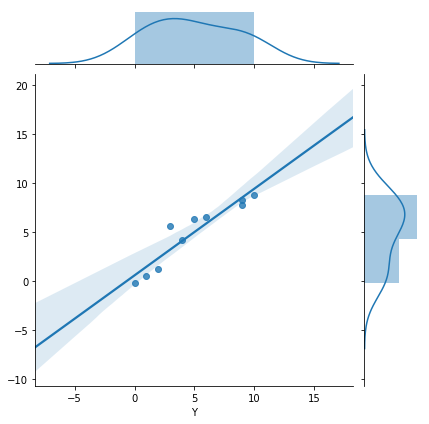

In [57]:
  
sns.jointplot(student_data.Y,model_fit.predict(X), kind='reg')

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

In [50]:
import statsmodels.stats.api as sms

result=model_fit

sms.linear_harvey_collier(result)

# pvalue>0.05; linearity confirmed; age is a good predictor for tardiness

Ttest_1sampResult(statistic=-0.7303519542513459, pvalue=0.4926948761596859)

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [51]:
import pandas as pd


In [53]:
df=pd.read_csv('vehicles.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
Make                       35952 non-null object
Model                      35952 non-null object
Year                       35952 non-null int64
Engine Displacement        35952 non-null float64
Cylinders                  35952 non-null float64
Transmission               35952 non-null object
Drivetrain                 35952 non-null object
Vehicle Class              35952 non-null object
Fuel Type                  35952 non-null object
Fuel Barrels/Year          35952 non-null float64
City MPG                   35952 non-null int64
Highway MPG                35952 non-null int64
Combined MPG               35952 non-null int64
CO2 Emission Grams/Mile    35952 non-null float64
Fuel Cost/Year             35952 non-null int64
dtypes: float64(4), int64(5), object(6)
memory usage: 4.1+ MB


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [70]:
df1.head()

,Year,Cylinders,Fuel Barrels/Year,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,1984,4.0,19.388824,17,522.764706,1950
1,1984,6.0,25.354615,13,683.615385,2550
2,1985,4.0,20.600625,16,555.437500,2100
3,1985,6.0,25.354615,13,683.615385,2550
4,1987,6.0,20.600625,16,555.437500,2550


In [84]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 6 columns):
Year                       35952 non-null int64
Cylinders                  35952 non-null float64
Fuel Barrels/Year          35952 non-null float64
Combined MPG               35952 non-null int64
CO2 Emission Grams/Mile    35952 non-null float64
Fuel Cost/Year             35952 non-null int64
dtypes: float64(3), int64(3)
memory usage: 1.6 MB


In [75]:
# df1=df.drop(['Make','Model','Engine Displacement','Transmission','Drivetrain','Vehicle Class','Fuel Type','City MPG','Highway MPG'], axis=1)
# df1
df1.corr()['CO2 Emission Grams/Mile']
# all selected variables have a good correlation with the CO2 Emissions, we take in the model all variables

,Year,Cylinders,Fuel Barrels/Year,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
Year,1.000000,0.082469,-0.221084,0.204751,-0.222300,-0.091913
Cylinders,0.082469,1.000000,0.739517,-0.698648,0.752393,0.778153
Fuel Barrels/Year,-0.221084,0.739517,1.000000,-0.909743,0.986189,0.916208
Combined MPG,0.204751,-0.698648,-0.909743,1.000000,-0.926229,-0.875185
CO2 Emission Grams/Mile,-0.222300,0.752393,0.986189,-0.926229,1.000000,0.930865
Fuel Cost/Year,-0.091913,0.778153,0.916208,-0.875185,0.930865,1.000000


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [80]:
# multiregression model 

X=df1.drop('CO2 Emission Grams/Mile', axis=1)
y=df1['CO2 Emission Grams/Mile']

X=add_constant(X)

model=sm.OLS(y,X)
model_fit2=model.fit()
model_fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Mon, 09 Sep 2019   Prob (F-statistic):               0.00
Time:                             16:31:21   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               769.8883     19.392     39.702      0.000     731.880     807.897
Year                 -0.3206      0.010    -33.060      0.000      -0.340      -0.302
Cylinders             1.8788      0.083     22.598      0.000       1.716       2.042
Fuel Barrels/Year    19.0529      0.061    311.600      0.000      18.933      19.173
Combined MPG         -3.0404      0.042    -71.645      0.000      -3.124      -2.957
Fuel Cost/Year        0.0323      0.000     67.025      0.000       0.031       0.033
==============================================================================
Omnibus:                    71055.645   Durbin-Watson:                   0.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        246941260.782
Skew:                          15.902   Prob(JB):                         0.00
Kurtosis:                     407.766   Cond. No.                     6.20e+05
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.2e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [82]:

import statsmodels.stats.api as sms
result2=model_fit2

sms.linear_harvey_collier(result2)
# model non good, overfitted, actually the variables are categorical (Cylinders below)

Ttest_1sampResult(statistic=nan, pvalue=nan)

In [85]:
df1.Cylinders.value_counts()

4.0     13494
6.0     12765
8.0      7998
5.0       723
12.0      562
3.0       201
10.0      153
2.0        48
16.0        8
Name: Cylinders, dtype: int64

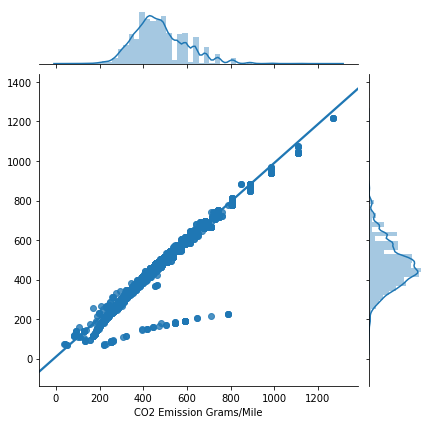

In [86]:
  
sns.jointplot(y,model_fit2.predict(X), kind='reg')

# Homoskedasticity

In [103]:
sms.diagnostic.het_breuschpagan(result2.resid, X)
# p-value is less than 5%, null hypothesis for this tests is rejected in favor of heteroscedasticity of the model

(9470.191879827511, 0.0, 2570.9386290203397, 0.0)

# Multicolinearity

In [97]:

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
VIF_results=pd.Series([vif(X.values,i) for i in range(X.shape[1])],index=X.columns)
VIF_results[VIF_results>10]
#there is no multicollinearity among the variables 
#i is columns

const    49857.072861
dtype: float64

In [100]:
VIF_results

const                49857.072861
Year                     1.268301
Cylinders                2.823492
Fuel Barrels/Year        9.892214
Combined MPG             6.240396
Fuel Cost/Year           7.917794
dtype: float64

In [101]:
df1.columns
#to look at the index 

Index(['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG',
       'CO2 Emission Grams/Mile', 'Fuel Cost/Year'],
      dtype='object')

# Normality of residuals

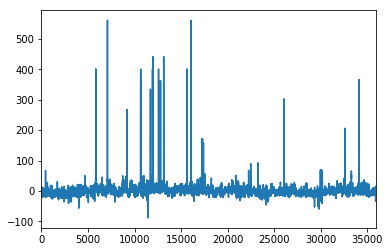

In [90]:
result2.resid.plot()
#residulas means the diference between the value predicted by the model and the real value 

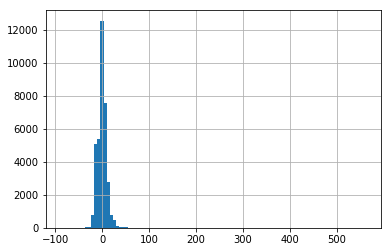

In [91]:
result2.resid.hist(bins=100)

In [95]:
sms.jarque_bera(result2.resid)

(246941260.78232345, 0.0, 15.901912452647965, 407.7663774504987)

In [93]:
from scipy.stats import ks_2samp
ks_2samp(y,model_fit2.predict(X))

Ks_2sampResult(statistic=0.06625500667556738, pvalue=4.338500090691283e-69)

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [106]:
df_invit = pd.DataFrame({'X': [1,3,4,6,8,9,11,14], 'Y': [1,2,4,4,5,7,8,13]})
df_invit

,X,Y
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8
7,14,13


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

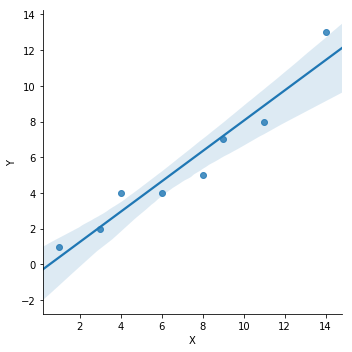

In [107]:

sns.lmplot('X','Y',data=df_invit,fit_reg=1)

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

In [108]:
X=df_invit.X
y=df_invit.Y

X=add_constant(X)

model=sm.OLS(y,X)
model_fitinv=model.fit()
model_fitinv.summary()
# the dependent Y is positively correlated with the independent variable X, the model is linear regression 

C:\Users\anast\Anaconda3\lib\site-packages\scipy\stats\stats.py:1416: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     81.81
Date:                Mon, 09 Sep 2019   Prob (F-statistic):           0.000102
Time:                        17:48:25   Log-Likelihood:                -10.800
No. Observations:                   8   AIC:                             25.60
Df Residuals:                       6   BIC:                             25.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4394      0.759     -0.579      0.584      -2.297       1.418
X              0.8485      0.094      9.045      0.000       0.619       1.078
==============================================================================
Omnibus:                        0.556   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.757   Jarque-Bera (JB):                0.514
Skew:                           0.261   Prob(JB):                        0.773
Kurtosis:                       1.873   Cond. No.                         16.3
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [5]:
# Your response here. 

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

In [ ]:
# Your response here. 